# Traffic Light Dataset Analysis and Preparation

This notebook performs data loading, cleaning, exploratory data analysis (EDA), visualization, and preparation for training a neural network to detect traffic light centers.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import os
import glob
from tqdm import tqdm

# Set matplotlib style
plt.style.use('ggplot')

# Define dataset base path
DATASET_BASE_PATH = "/Users/antonhorobets/PycharmProjects/PythonProject2/Kaggle Archive"
ANNOTATIONS_PATH = os.path.join(DATASET_BASE_PATH, "Annotations", "Annotations")

## 1. Data Loading and Cleaning

We load the CSV annotations, parse the complex folder structure to find the actual image paths, and calculate bounding box centers.

In [5]:
def get_image_path_from_filename(filename, base_path):
    actual_filename = os.path.basename(filename)
    prefix = actual_filename.split('--')[0]
    
    if "Sequence" in prefix:
        return os.path.join(base_path, prefix, prefix, "frames", actual_filename)
    elif "Clip" in prefix:
        if "day" in prefix:
             return os.path.join(base_path, "dayTrain", "dayTrain", prefix, "frames", actual_filename)
        elif "night" in prefix:
             return os.path.join(base_path, "nightTrain", "nightTrain", prefix, "frames", actual_filename)
    return None

def load_and_preprocess_annotations(base_path, annotation_type):
    search_pattern = os.path.join(base_path, "**", f"*frameAnnotations{annotation_type}.csv")
    csv_files = glob.glob(search_pattern, recursive=True)
    
    if not csv_files:
        print(f"No {annotation_type} files found.")
        return pd.DataFrame()

    all_data = []
    column_names = [
        "Filename", "Annotation tag", "Upper left corner X", "Upper left corner Y",
        "Lower right corner X", "Lower right corner Y", "Origin file",
        "Origin frame number", "Origin track", "Origin track frame number"
    ]

    for f in csv_files:
        try:
            df = pd.read_csv(f, sep=';', names=column_names, header=0)
            all_data.append(df)
        except Exception as e:
            print(f"Error reading {f}: {e}")

    combined_df = pd.concat(all_data, ignore_index=True)

    coord_cols = ["Upper left corner X", "Upper left corner Y", "Lower right corner X", "Lower right corner Y"]
    for col in coord_cols:
        combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
    
    combined_df.dropna(subset=coord_cols, inplace=True)

    combined_df['width'] = combined_df['Lower right corner X'] - combined_df['Upper left corner X']
    combined_df['height'] = combined_df['Lower right corner Y'] - combined_df['Upper left corner Y']
    combined_df['center_x'] = combined_df['Upper left corner X'] + (combined_df['width'] / 2)
    combined_df['center_y'] = combined_df['Upper left corner Y'] + (combined_df['height'] / 2)
    
    combined_df['file_path'] = combined_df['Filename'].apply(lambda x: get_image_path_from_filename(x, DATASET_BASE_PATH))
    

    return combined_df

print("Loading BOX annotations...")
box_df = load_and_preprocess_annotations(ANNOTATIONS_PATH, "BOX")
print(f"Loaded {len(box_df)} BOX annotations.")


Loading BOX annotations...
Loaded 109475 BOX annotations.


## 2. Exploratory Data Analysis (EDA)

Understanding the distribution of classes and bounding box dimensions.

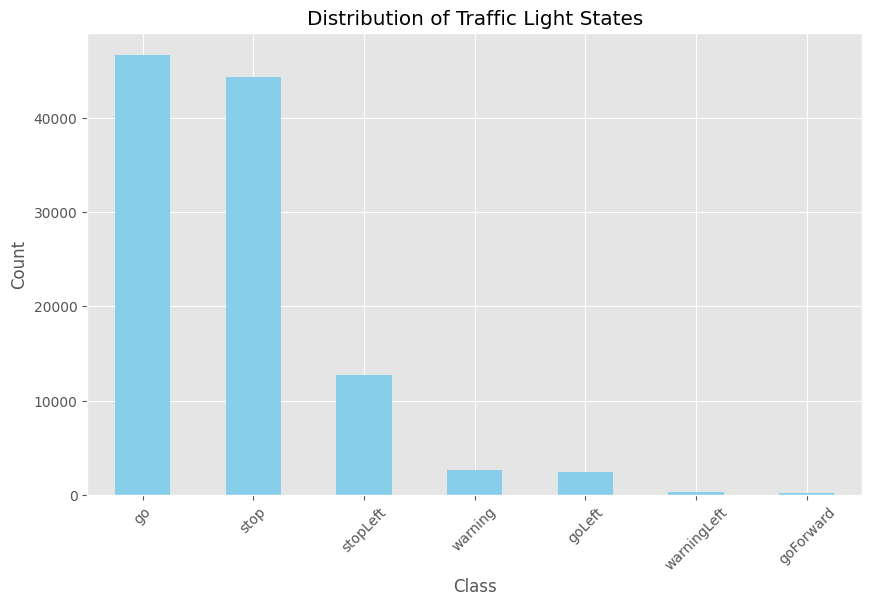

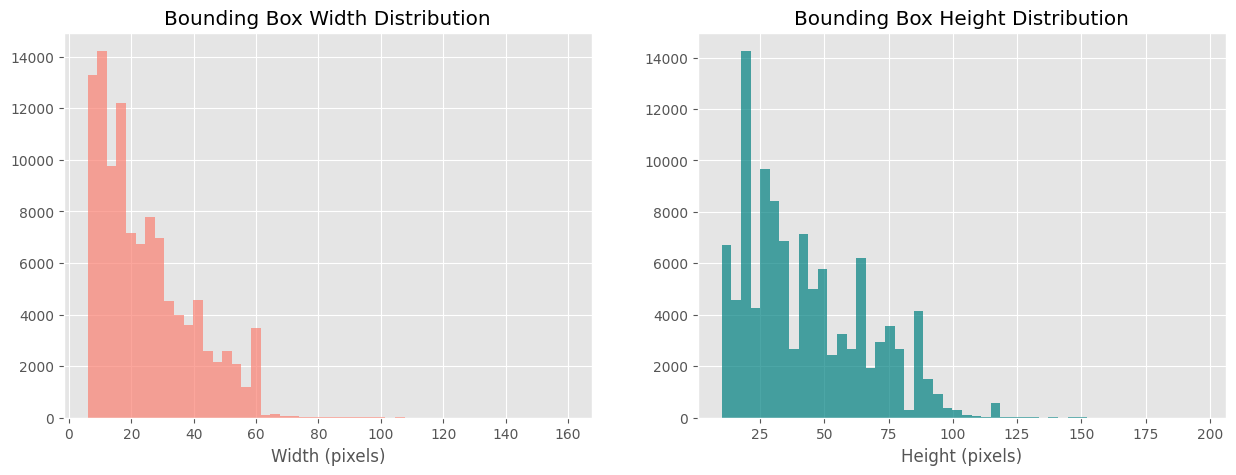

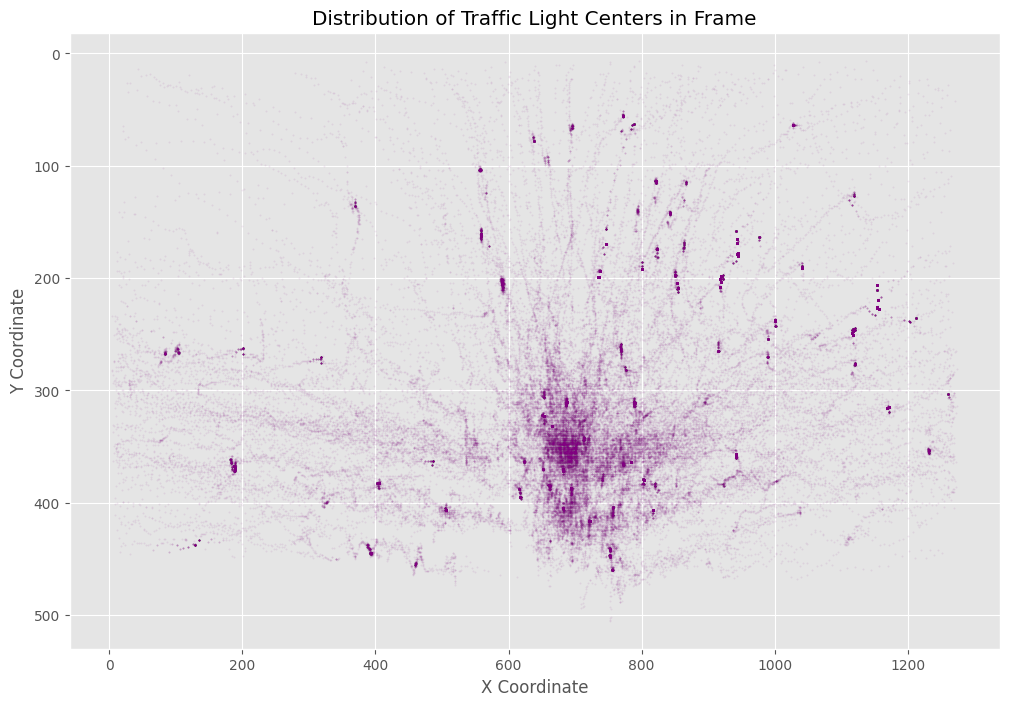

In [6]:
plt.figure(figsize=(10, 6))
box_df['Annotation tag'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Traffic Light States')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(box_df['width'], bins=50, color='salmon', alpha=0.7)
axes[0].set_title('Bounding Box Width Distribution')
axes[0].set_xlabel('Width (pixels)')

axes[1].hist(box_df['height'], bins=50, color='teal', alpha=0.7)
axes[1].set_title('Bounding Box Height Distribution')
axes[1].set_xlabel('Height (pixels)')

plt.show()

plt.figure(figsize=(12, 8))
plt.scatter(box_df['center_x'], box_df['center_y'], alpha=0.05, s=1, c='purple')
plt.title('Distribution of Traffic Light Centers in Frame')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.gca().invert_yaxis()
plt.show()

## 3. Visual Inspection

Let's visualize some random samples to verify our coordinate parsing and bounding boxes.

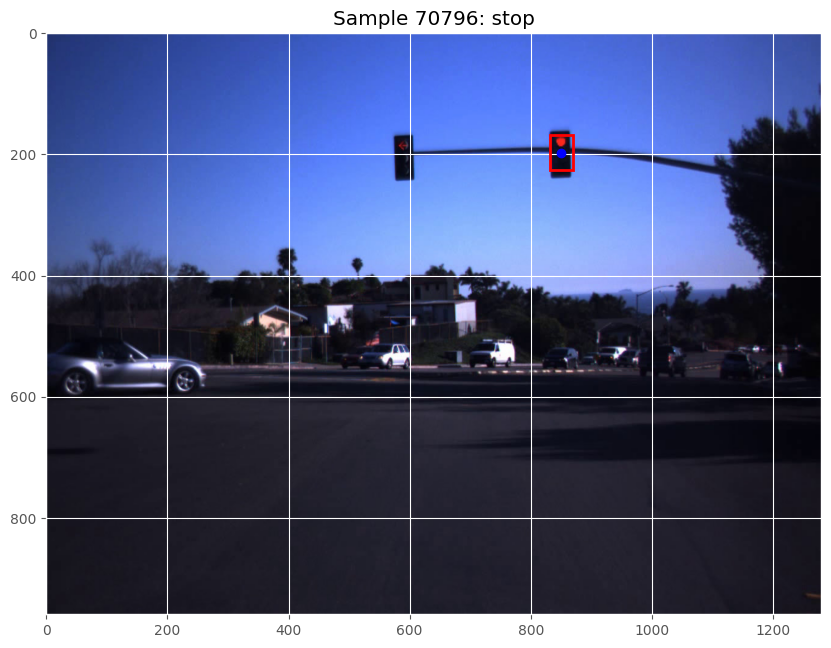

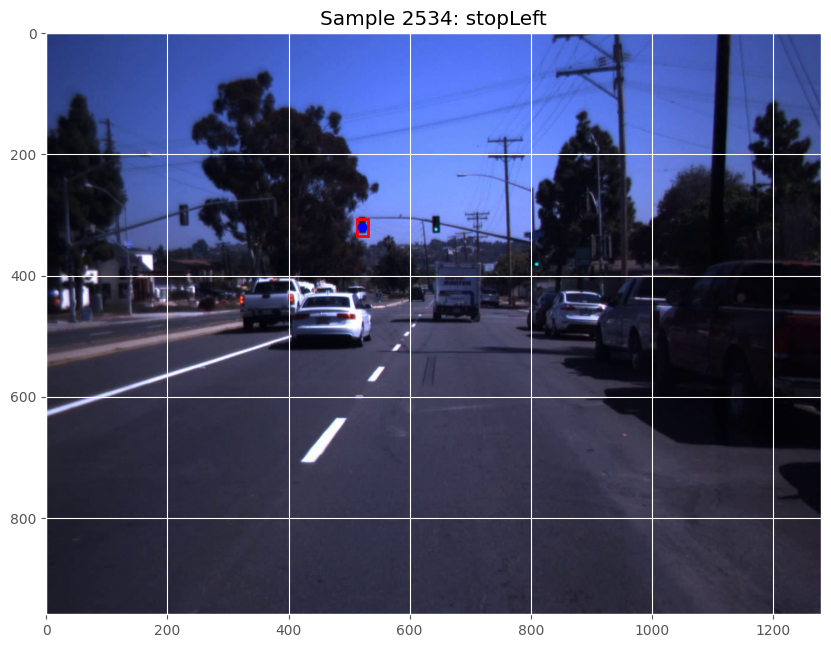

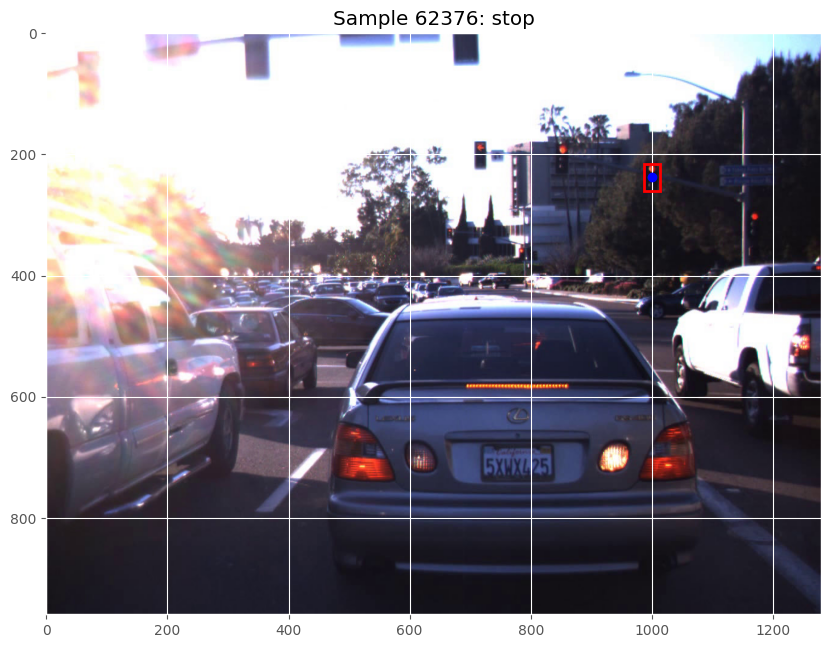

In [29]:
def show_sample(df, index):
    row = df.iloc[index]
    img_path = row['file_path']
    
    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
        return
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img)
    
    # Draw box
    rect = patches.Rectangle(
        (row['Upper left corner X'], row['Upper left corner Y']),
        row['width'], row['height'],
        linewidth=2, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)
    
    # Draw center
    ax.plot(row['center_x'], row['center_y'], 'bo')
    
    ax.set_title(f"Sample {index}: {row['Annotation tag']}")
    plt.show()

import random
indices = random.sample(range(len(box_df)), 3)
for idx in indices:
    show_sample(box_df, idx)

## 4. Data Preparation for Training

### Resizing and Normalization
Neural networks require fixed input sizes (e.g., 224x224 or 640x640). We also normalize coordinates to [0, 1] range.

In [8]:
TARGET_SIZE = (224, 224)
ORIGINAL_SIZE = (1280, 960)

def resize_and_normalize(row, target_size=TARGET_SIZE, original_size=ORIGINAL_SIZE):
    # Normalization
    norm_center_x = row['center_x'] / original_size[0]
    norm_center_y = row['center_y'] / original_size[1]
    norm_width = row['width'] / original_size[0]
    norm_height = row['height'] / original_size[1]
    
    return pd.Series([norm_center_x, norm_center_y, norm_width, norm_height])

box_df[['norm_center_x', 'norm_center_y', 'norm_width', 'norm_height']] = box_df.apply(resize_and_normalize, axis=1)

print(box_df[['center_x', 'center_y', 'norm_center_x', 'norm_center_y']].head())

   center_x  center_y  norm_center_x  norm_center_y
0    1185.5     361.0       0.926172       0.376042
1    1159.5     364.5       0.905859       0.379688
2    1133.5     364.5       0.885547       0.379688
3    1107.5     361.0       0.865234       0.376042
4    1083.0     361.0       0.846094       0.376042


### Visualize Resized Image
Verify that resizing works by transforming an image and plotting the normalized coordinates back onto it.

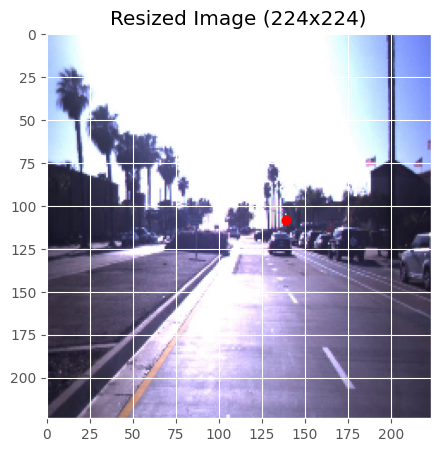

In [9]:
def show_resized_sample(df, index, target_size=TARGET_SIZE):
    row = df.iloc[index]
    img_path = row['file_path']
    
    if not os.path.exists(img_path):
        return
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img, target_size)
    
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(img_resized)
    
    rx = row['norm_center_x'] * target_size[0]
    ry = row['norm_center_y'] * target_size[1]
    rw = row['norm_width'] * target_size[0]
    rh = row['norm_height'] * target_size[1]
    
    top_left_x = rx - (rw / 2)
    top_left_y = ry - (rh / 2)
    
    rect = patches.Rectangle(
        (top_left_x, top_left_y),
        rw, rh,
        linewidth=2, edgecolor='g', facecolor='none'
    )
    ax.add_patch(rect)
    ax.plot(rx, ry, 'ro')
    ax.set_title("Resized Image (224x224)")
    plt.show()

show_resized_sample(box_df, indices[0])

### Splitting the Dataset
We split the data into Train, Validation, and Test sets respecting the sequence structure described:
- **Test**: `daySequence1`, `daySequence2`, `nightSequence1`, `nightSequence2`
- **Train**: `dayClip*`, `nightClip*` (We will split this further into Train and Val)

In [30]:
import pandas as pd

df_shuffled = box_df.sample(frac=1, random_state=42).reset_index(drop=True)

test_df = df_shuffled.groupby('Annotation tag', group_keys=False).apply(
    lambda x: x.sample(frac=0.1, random_state=42)
)

remaining_df = df_shuffled.drop(test_df.index)

val_df = remaining_df.groupby('Annotation tag', group_keys=False).apply(
    lambda x: x.sample(frac=0.1111, random_state=42)
)

train_df = remaining_df.drop(val_df.index)

print(f"Total rows: {len(box_df)}")
print("-" * 30)
print(f"Train set size (80%): {len(train_df)}")
print(f"Val set size   (10%): {len(val_df)}")
print(f"Test set size  (10%): {len(test_df)}")

# Сохраняем
train_df.to_csv("train_annotations.csv", index=False)
val_df.to_csv("val_annotations.csv", index=False)
test_df.to_csv("test_annotations.csv", index=False)

print("\nDatasets saved successfully.")

/var/folders/6r/108zsvrx7ks4slv4vj44rb8c0000gn/T/ipykernel_25212/2060055266.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = df_shuffled.groupby('Annotation tag', group_keys=False).apply(
/var/folders/6r/108zsvrx7ks4slv4vj44rb8c0000gn/T/ipykernel_25212/2060055266.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_df = remaining_df.groupby('Annotation tag', group_keys=False).apply(


Total rows: 109475
------------------------------
Train set size (80%): 87581
Val set size   (10%): 10947
Test set size  (10%): 10947

Datasets saved successfully.


## 5. Pytorch Dataset Template

Below is a template for a custom PyTorch Dataset class that uses the CSVs prepared above. This handles on-the-fly resizing and normalization.

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class TrafficLightDataset(Dataset):
    def __init__(self, csv_file, root_dir, target_size=(224, 224), transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.target_size = target_size
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]
        img_path = row['file_path']
        
        image = cv2.imread(img_path)
        if image is None:
             return self.__getitem__((idx + 1) % len(self))
             
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.target_size)
        
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)
        
        target = torch.tensor([
            row['norm_center_x'], 
            row['norm_center_y']
        ], dtype=torch.float32)
        
        return image, target

